# Hybrid Semantic Retrieval & Intelligence System (HSRIS)

**Platform:** Kaggle Notebook — Dual T4 x2 GPU  
**Framework:** PyTorch + NumPy
**Dataset:** Customer Support Ticket Dataset (~8,470 records)


---
## 1 - Environment Setup & Imports


In [47]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1: Environment Setup
# ─────────────────────────────────────────────────────────────────
import os
import re
import math
import time
import random
import zipfile
import urllib.request
import collections
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── GPU Configuration ──────────────────────────────────────────────
NUM_GPUS = torch.cuda.device_count()
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'Number of GPUs  : {NUM_GPUS}')
for i in range(NUM_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
print(f'Primary device  : {device}')

PyTorch version : 2.9.0+cu126
CUDA available  : True
Number of GPUs  : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Primary device  : cuda


---
## 2 - Dataset Loading

The dataset contains ~8,470 customer support records across multiple channels and priority levels.

**Focus columns:**
| Column | Role |
|---|---|
| `Ticket Subject` | Short title of the ticket |
| `Ticket Description` | Full problem description |
| `Ticket Priority` | Low / Medium / High |
| `Ticket Type` | Category label for evaluation |
| `Ticket Channel` | Email / Chat / Phone / Social Media |

In [48]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2: Dataset Loading
# ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import re
from collections import Counter
import time
import math
import os
print("Loading Dataset...")
print("-"*50)
# Dataset path
dataset_path = '/kaggle/input/customer-support-ticket-dataset/customer_support_tickets.csv'
# Check if file exists
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print(f"Dataset loaded successfully!")
    print(f"Total records: {len(df)}")
    print(f"Total columns: {len(df.columns)}")
else:
    # Try to find the file automatically
    input_dir = '/kaggle/input'
    found = False
    for dirname, _, filenames in os.walk(input_dir):
        for filename in filenames:
            if filename.endswith('.csv'):
                dataset_path = os.path.join(dirname, filename)
                df = pd.read_csv(dataset_path)
                print(f"Dataset found at: {dataset_path}")
                print(f"Total records: {len(df)}")
                found = True
                break
        if found:
            break
print(f"\nDataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Loading Dataset...
--------------------------------------------------
Dataset found at: /kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv
Total records: 8469

Dataset shape: (8469, 17)
Memory usage: 1.10 MB


In [49]:
# ── Select & rename focus columns ──────────────────────────────────
FOCUS_COLS = {
    'Ticket Subject'    : 'subject',
    'Ticket Description': 'description',
    'Ticket Priority'   : 'priority',
    'Ticket Type'       : 'ticket_type',
    'Ticket Channel'    : 'channel',
}

df = df[list(FOCUS_COLS.keys())].rename(columns=FOCUS_COLS)

# Drop rows missing any focus column
df = df.dropna(subset=['subject', 'description', 'priority', 'ticket_type', 'channel'])
df = df.reset_index(drop=True)

# Combine subject + description into a single text field for retrieval
df['text'] = df['subject'].str.strip() + ' ' + df['description'].str.strip()

print(f'Clean dataset size: {len(df)}')
print('\nPriority distribution:')
print(df['priority'].value_counts())
print('\nChannel distribution:')
print(df['channel'].value_counts())
print('\nTicket Type distribution:')
print(df['ticket_type'].value_counts())

Clean dataset size: 8469

Priority distribution:
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Channel distribution:
channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Ticket Type distribution:
ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


---
## 3 - Data Preprocessing

The pipeline performs:
1. **Lowercasing** — normalise case
2. **URL removal** — strip http links
3. **Punctuation removal** — via regex character class
4. **Extra-whitespace normalisation**
5. **Minimum token length filter** — remove single characters

In [50]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3: Custom Preprocessing Pipeline
# ─────────────────────────────────────────────────────────────────

# Compile regex patterns once for efficiency
_RE_URL   = re.compile(r'https?://\S+|www\.\S+')
_RE_PUNCT = re.compile(r'[^\w\s]')          # keep alphanumerics & spaces
_RE_SPACE = re.compile(r'\s+')

def preprocess_text(text: str) -> str:
    """
    Clean raw text for tokenisation.
    Steps: lowercase → strip URLs → remove punctuation → collapse spaces.
    """
    text = str(text).lower()               # 1. Lowercase
    text = _RE_URL.sub(' ', text)          # 2. Remove URLs
    text = _RE_PUNCT.sub(' ', text)        # 3. Remove punctuation
    text = _RE_SPACE.sub(' ', text).strip()# 4. Collapse whitespace
    return text


def tokenize(text: str) -> list:
    """
    Tokenise preprocessed text by whitespace splitting.
    Filters out single-character tokens.
    """
    return [tok for tok in text.split() if len(tok) > 1]


# Apply to all texts — maintain exact index alignment with df
print('Preprocessing texts...')
t0 = time.time()
df['clean_text'] = df['text'].apply(preprocess_text)
df['tokens']     = df['clean_text'].apply(tokenize)
print(f'Done in {time.time()-t0:.2f}s')

# Sanity check
print('\nSample original :', df['text'].iloc[0][:120])
print('Sample cleaned  :', df['clean_text'].iloc[0][:120])
print('Sample tokens   :', df['tokens'].iloc[0][:15])

Preprocessing texts...
Done in 0.56s

Sample original : Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We app
Sample cleaned  : product setup i m having an issue with the product_purchased please assist your billing zip code is 71701 we appreciate 
Sample tokens   : ['product', 'setup', 'having', 'an', 'issue', 'with', 'the', 'product_purchased', 'please', 'assist', 'your', 'billing', 'zip', 'code', 'is']


---
## 4 - Custom Tokenization & Vocabulary Building

1. Count all token frequencies across the corpus.
2. Keep the **top 5,000** most frequent tokens (the vocabulary).
3. Assign each token a unique integer index.
4. Generate **N-grams** (bigrams and trigrams) using a sliding window.

### N-Grams
An **n-gram** is a contiguous sequence of `n` tokens. Bigrams capture two-word context (e.g., "billing issue"), and trigrams capture three-word context (e.g., "cannot access account").

In [51]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4: Vocabulary & N-Gram Builder
# ─────────────────────────────────────────────────────────────────
import collections

VOCAB_SIZE = 5000

# ── Step 1: Count global token frequencies ────────────────────────
print('Building vocabulary from corpus...')
freq_counter = collections.Counter()
for tokens in df['tokens']:
    freq_counter.update(tokens)

print(f'Total unique tokens in corpus : {len(freq_counter):,}')

# ── Step 2: Select top-N tokens ──────────────────────────────────
top_tokens = [tok for tok, _ in freq_counter.most_common(VOCAB_SIZE)]

# Reserve index 0 for <PAD> and 1 for <UNK>
vocab      = {'<PAD>': 0, '<UNK>': 1}
vocab.update({tok: idx + 2 for idx, tok in enumerate(top_tokens)})
inv_vocab  = {idx: tok for tok, idx in vocab.items()}

EFFECTIVE_VOCAB = len(vocab)
print(f'Vocabulary size (with specials): {EFFECTIVE_VOCAB}')
print('Top 20 tokens:', list(vocab.keys())[2:22])


# ── Step 3: N-Gram generator (sliding window) ─────────────────────
def generate_ngrams(tokens: list, n: int) -> list:
    """
    Generate n-grams from a token list using a sliding window.
    Args:
        tokens : list of string tokens
        n      : gram size (2=bigram, 3=trigram)
    Returns:
        list of tuples, each tuple is one n-gram
    """
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


# Demonstrate n-grams on the first document
example_tokens = df['tokens'].iloc[0]
bigrams  = generate_ngrams(example_tokens, 2)
trigrams = generate_ngrams(example_tokens, 3)
print('\nExample tokens  :', example_tokens[:8])
print('Bigrams (first 5):', bigrams[:5])
print('Trigrams (first 5):', trigrams[:5])

# Build bigram & trigram frequency tables over entire corpus
bigram_freq  = collections.Counter()
trigram_freq = collections.Counter()
for tokens in df['tokens']:
    bigram_freq.update(generate_ngrams(tokens, 2))
    trigram_freq.update(generate_ngrams(tokens, 3))

print(f'\nTotal unique bigrams  : {len(bigram_freq):,}')
print(f'Total unique trigrams : {len(trigram_freq):,}')
print('Top 10 bigrams  :', bigram_freq.most_common(10))
print('Top 10 trigrams :', trigram_freq.most_common(10))

Building vocabulary from corpus...
Total unique tokens in corpus : 6,886
Vocabulary size (with specials): 5002
Top 20 tokens: ['the', 'product_purchased', 'issue', 'to', 'my', 'please', 'it', 'with', 'an', 'having', 'assist', 've', 'and', 'is', 'you', 'but', 'this', 'on', 'product', 'problem']

Example tokens  : ['product', 'setup', 'having', 'an', 'issue', 'with', 'the', 'product_purchased']
Bigrams (first 5): [('product', 'setup'), ('setup', 'having'), ('having', 'an'), ('an', 'issue'), ('issue', 'with')]
Trigrams (first 5): [('product', 'setup', 'having'), ('setup', 'having', 'an'), ('having', 'an', 'issue'), ('an', 'issue', 'with'), ('issue', 'with', 'the')]

Total unique bigrams  : 50,943
Total unique trigrams : 101,598
Top 10 bigrams  : [(('the', 'product_purchased'), 7915), (('with', 'the'), 6417), (('issue', 'with'), 6395), (('an', 'issue'), 6285), (('please', 'assist'), 6247), (('having', 'an'), 6173), (('product_purchased', 'please'), 6117), (('my', 'product_purchased'), 5863

---
## 5 - Categorical Encoders

### 5.1 Label Encoding - Ticket Priority

**Label encoding** maps each discrete category to a unique integer. For `Ticket Priority` we use a fixed, domain-meaningful mapping:

| Priority | Integer |
|---|---|
| Low | 0 |
| Medium | 1 |
| High | 2 |

Unseen categories during inference default to `-1` (graceful fallback).

### 5.2 One-Hot Encoding - Ticket Channel

**One-hot encoding** creates a binary vector of length `|C|` (number of categories). Only the position corresponding to the category is set to `1`; all others are `0`. We implement this using pure NumPy and PyTorch without any library encoder.

In [52]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5: Categorical Encoders
# ─────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# 5.1  Label Encoder (Ticket Priority)
# ══════════════════════════════════════════════════════════════════

class LabelEncoderCustom:
    """
    Manual label encoder mapping category strings to integers.
    Handles unseen categories at inference time by returning -1.
    """
    def __init__(self, mapping: dict):
        self.mapping     = mapping                    # str → int
        self.inv_mapping = {v: k for k, v in mapping.items()}  # int → str

    def encode(self, value: str) -> int:
        """Encode a single category. Returns -1 for unseen categories."""
        return self.mapping.get(str(value).strip(), -1)

    def encode_series(self, series) -> np.ndarray:
        """Encode a pandas Series or list of categories."""
        return np.array([self.encode(v) for v in series], dtype=np.int64)

    def decode(self, idx: int) -> str:
        """Decode integer back to category string."""
        return self.inv_mapping.get(idx, '<UNSEEN>')


# Fixed priority mapping (Low < Medium < High reflects ordinal severity)
priority_encoder = LabelEncoderCustom({'Low': 0, 'Medium': 1, 'High': 2})
priority_labels  = priority_encoder.encode_series(df['priority'])

print('Label Encoding — Ticket Priority')
print('Mapping:', priority_encoder.mapping)
print('Encoded (first 10):', priority_labels[:10])
print('Unseen category test ("Critical"):', priority_encoder.encode('Critical'))

# ══════════════════════════════════════════════════════════════════
# 5.2  One-Hot Encoder (Ticket Channel)
# ══════════════════════════════════════════════════════════════════

class OneHotEncoderCustom:
    """
    Manual one-hot encoder.
    Discovers categories from training data and builds binary vectors.
    """
    def __init__(self):
        self.categories  = None   # sorted list of category strings
        self.cat_to_idx  = None   # str → int position
        self.num_classes = 0

    def fit(self, series) -> 'OneHotEncoderCustom':
        """Learn category set from data."""
        self.categories  = sorted(set(str(v).strip() for v in series))
        self.cat_to_idx  = {cat: i for i, cat in enumerate(self.categories)}
        self.num_classes = len(self.categories)
        return self

    def transform(self, series) -> np.ndarray:
        """
        Convert a list/series of categories into a 2-D binary matrix.
        Shape: (N, num_classes). Unseen categories produce an all-zero row.
        """
        N   = len(series)
        ohe = np.zeros((N, self.num_classes), dtype=np.float32)
        for row, val in enumerate(series):
            idx = self.cat_to_idx.get(str(val).strip(), None)
            if idx is not None:
                ohe[row, idx] = 1.0
        return ohe

    def transform_single(self, value: str) -> np.ndarray:
        """Encode a single value → shape (num_classes,)."""
        vec = np.zeros(self.num_classes, dtype=np.float32)
        idx = self.cat_to_idx.get(str(value).strip(), None)
        if idx is not None:
            vec[idx] = 1.0
        return vec


channel_encoder = OneHotEncoderCustom().fit(df['channel'])
channel_ohe     = channel_encoder.transform(df['channel'])

print('\nOne-Hot Encoding — Ticket Channel')
print('Categories discovered:', channel_encoder.categories)
print('OHE matrix shape     :', channel_ohe.shape)
print('Example row (Email)  :', channel_encoder.transform_single('Email'))

# Store encoded labels in df for later alignment checks
df['priority_label'] = priority_labels

Label Encoding — Ticket Priority
Mapping: {'Low': 0, 'Medium': 1, 'High': 2}
Encoded (first 10): [-1 -1  0  0  0  0 -1 -1  0 -1]
Unseen category test ("Critical"): -1

One-Hot Encoding — Ticket Channel
Categories discovered: ['Chat', 'Email', 'Phone', 'Social media']
OHE matrix shape     : (8469, 4)
Example row (Email)  : [0. 1. 0. 0.]


---
## 6 - TF-IDF Implementation

### Bag of Words (Count Vectorizer)
We first construct a **term-frequency** matrix: for each document `d` and term `t`, we count how many times `t` appears in `d`.

### Sparse Storage
The TF-IDF matrix is `(N_docs × VOCAB_SIZE)` = ~8,470 × 5,000 = ~42M cells. Most values are **zero** (each document uses a tiny fraction of the vocabulary). We use **`torch.sparse_coo_tensor`** to store only the non-zero entries, dramatically reducing memory usage.

In [53]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6: TF-IDF from Scratch with Sparse Tensor Storage
# ─────────────────────────────────────────────────────────────────

N_DOCS = len(df)

# ── Step 1: Compute document frequency (df_t) ─────────────────────
# df_t[t] = number of documents that contain token t
print('Computing document frequencies...')
doc_freq = np.zeros(EFFECTIVE_VOCAB, dtype=np.int64)

for tokens in df['tokens']:
    seen = set()
    for tok in tokens:
        idx = vocab.get(tok, 1)   # 1 = <UNK>
        if idx not in seen:
            doc_freq[idx] += 1
            seen.add(idx)

# ── Step 2: Compute IDF vector ────────────────────────────────────
# Smoothed IDF to avoid division-by-zero and dampen common terms
idf_vector = np.log((N_DOCS + 1) / (doc_freq + 1)) + 1.0  # shape: (VOCAB,)
idf_tensor = torch.tensor(idf_vector, dtype=torch.float32)  # keep on CPU for now

print(f'IDF computed. Min: {idf_vector.min():.4f}, Max: {idf_vector.max():.4f}')

# ── Step 3: Build sparse TF-IDF matrix ───────────────────────────
# We collect COO (coordinate) triples: (row, col, value)
print('Building sparse TF-IDF matrix...')
t0 = time.time()

rows_list   = []
cols_list   = []
vals_list   = []

for doc_idx, tokens in enumerate(df['tokens']):
    if not tokens:
        continue
    n_tokens = len(tokens)

    # Count term frequencies in this document
    tf_counter = collections.Counter()
    for tok in tokens:
        t_idx = vocab.get(tok, 1)
        tf_counter[t_idx] += 1

    # Compute TF-IDF for each term
    for t_idx, count in tf_counter.items():
        tf_val  = count / n_tokens                  # normalised TF
        tfidf   = tf_val * idf_vector[t_idx]         # TF × IDF
        if tfidf > 0:
            rows_list.append(doc_idx)
            cols_list.append(t_idx)
            vals_list.append(tfidf)

# Convert to torch sparse COO tensor
indices = torch.tensor([rows_list, cols_list], dtype=torch.long)
values  = torch.tensor(vals_list, dtype=torch.float32)

tfidf_sparse = torch.sparse_coo_tensor(
    indices,
    values,
    size=(N_DOCS, EFFECTIVE_VOCAB)
).coalesce()  # merge duplicate indices

print(f'Sparse TF-IDF built in {time.time()-t0:.2f}s')
print(f'Shape          : {tfidf_sparse.shape}')
print(f'Non-zero entries: {tfidf_sparse._nnz():,}')
dense_mb = (N_DOCS * EFFECTIVE_VOCAB * 4) / (1024**2)
sparse_mb = (tfidf_sparse._nnz() * (4 + 4 + 4)) / (1024**2)
print(f'Dense size (est.) : {dense_mb:.1f} MB')
print(f'Sparse size (est.): {sparse_mb:.1f} MB')
print(f'Compression ratio : {dense_mb/sparse_mb:.1f}x')

Computing document frequencies...
IDF computed. Min: 1.0000, Max: 10.0443
Building sparse TF-IDF matrix...
Sparse TF-IDF built in 0.42s
Shape          : torch.Size([8469, 5002])
Non-zero entries: 314,569
Dense size (est.) : 161.6 MB
Sparse size (est.): 3.6 MB
Compression ratio : 44.9x


In [54]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4.5: TF-IDF Vector Normalization (UPDATED VERSION)
# ─────────────────────────────────────────────────────────────────

import torch
import collections

# Step 1: Define device (GPU if available else CPU)
print("="*50)
print("TF-IDF NORMALIZATION")
print("="*50)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Step 2: Check if required variables exist
required_vars = {
    'tfidf_sparse': 'TF-IDF sparse matrix',
    'idf_tensor': 'IDF tensor',
    'EFFECTIVE_VOCAB': 'Vocabulary size',
    'vocab': 'Vocabulary dictionary'
}

missing_vars = []
for var, desc in required_vars.items():
    if var not in locals() and var not in globals():
        missing_vars.append(f"{var} ({desc})")

if missing_vars:
    print("\nMissing required variables:")
    for var in missing_vars:
        print(f"   - {var}")
    print("\nPlease run previous sections first!")
else:
    print("\nAll required variables found!")
    
    # Step 3: Convert sparse to dense and normalize
    print('\nConverting sparse → dense and normalising rows...')
    
    try:
        # Check memory before conversion
        if hasattr(tfidf_sparse, 'shape'):
            n_rows, n_cols = tfidf_sparse.shape
            estimated_memory = n_rows * n_cols * 4 / (1024**3)  # GB for float32
            print(f"   Shape: ({n_rows}, {n_cols})")
            print(f"   Estimated dense memory: {estimated_memory:.2f} GB")
            
            if estimated_memory > 10:  # If more than 10GB
                print("Warning: Large matrix! This might cause memory issues.")
        
        # Convert to dense
        tfidf_dense = tfidf_sparse.to_dense()  # (N, VOCAB)
        print(f" Converted to dense: {tfidf_dense.shape}")
        
        # L2-norm per row; add epsilon to avoid NaN for zero rows
        row_norms = torch.norm(tfidf_dense, dim=1, keepdim=True).clamp(min=1e-10)
        tfidf_norm = tfidf_dense / row_norms  # unit vectors
        print("  L2 normalization complete")
        
        # Move to GPU/CPU
        tfidf_gpu = tfidf_norm.to(device)
        idf_gpu = idf_tensor.to(device)
        
        print(f"\n Final matrix:")
        print(f"   tfidf_gpu shape : {tfidf_gpu.shape}")
        print(f"   device          : {tfidf_gpu.device}")
        print(f"   dtype           : {tfidf_gpu.dtype}")
        
        # Memory usage
        if device.type == 'cuda':
            memory_allocated = torch.cuda.memory_allocated() / 1024**3
            print(f"   GPU memory used : {memory_allocated:.2f} GB")
        
        # Step 4: Define vectorize_query_tfidf function
        def vectorize_query_tfidf(query_tokens: list) -> torch.Tensor:
            """
            Convert a list of query tokens into a L2-normalised TF-IDF vector.
            Returns a 1-D tensor of shape (VOCAB,) on the same device as idf_gpu.
            
            Args:
                query_tokens: List of token strings
                
            Returns:
                Normalized TF-IDF vector tensor
            """
            # Initialize zero vector on same device as idf_gpu
            vec = torch.zeros(EFFECTIVE_VOCAB, device=idf_gpu.device, dtype=torch.float32)
            n = len(query_tokens)
            
            if n == 0:
                return vec
            
            # Count tokens in query
            counter = collections.Counter(query_tokens)
            
            # Build TF-IDF vector
            for tok, cnt in counter.items():
                t_idx = vocab.get(tok, 1)  # 1 is <UNK> index
                # TF = cnt/n, IDF = idf_gpu[t_idx]
                vec[t_idx] += (cnt / n) * idf_gpu[t_idx]
            
            # Normalize
            norm = vec.norm().clamp(min=1e-10)
            return vec / norm
        
        # Test the function with sample query
        print("\nTesting vectorize_query_tfidf function...")
        
        # Get sample tokens from first document
        if 'df' in locals() and 'tokens' in df.columns and len(df) > 0:
            sample_query = df['tokens'].iloc[0][:5]  # First 5 tokens of first doc
        else:
            sample_query = ['this', 'is', 'a', 'test', 'query']
        
        print(f"   Sample query: {sample_query}")
        
        # Run test
        test_vector = vectorize_query_tfidf(sample_query)
        print(f"   Output shape: {test_vector.shape}")
        print(f"   Vector norm : {test_vector.norm().item():.4f}")
        print(f"   Non-zero entries: {(test_vector != 0).sum().item()}")
        print(f"   Device       : {test_vector.device}")
        
        print("\n TF-IDF pipeline ready!")
        
        # Optional: Save normalized matrix for later use
        print("\n Saving normalized TF-IDF matrix...")
        torch.save({
            'tfidf_matrix': tfidf_gpu.cpu() if tfidf_gpu.device.type == 'cuda' else tfidf_gpu,
            'idf_vector': idf_gpu.cpu() if idf_gpu.device.type == 'cuda' else idf_gpu,
            'vocab': vocab,
            'device': device.type
        }, 'tfidf_normalized.pt')
        print("   Saved to 'tfidf_normalized.pt'")
        
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("\n CUDA out of memory error!")
            print("   Trying CPU fallback...")
            
            # Fallback to CPU
            device = torch.device('cpu')
            tfidf_dense = tfidf_sparse.to_dense()
            row_norms = torch.norm(tfidf_dense, dim=1, keepdim=True).clamp(min=1e-10)
            tfidf_norm = tfidf_dense / row_norms
            tfidf_gpu = tfidf_norm
            idf_gpu = idf_tensor
            
            print(f"    Completed on CPU")
            print(f"   tfidf_gpu shape : {tfidf_gpu.shape}")
            
            def vectorize_query_tfidf(query_tokens: list) -> torch.Tensor:
                vec = torch.zeros(EFFECTIVE_VOCAB, dtype=torch.float32)
                n = len(query_tokens)
                if n == 0:
                    return vec
                counter = collections.Counter(query_tokens)
                for tok, cnt in counter.items():
                    t_idx = vocab.get(tok, 1)
                    vec[t_idx] += (cnt / n) * idf_gpu[t_idx]
                norm = vec.norm().clamp(min=1e-10)
                return vec / norm
            
            print("\n TF-IDF pipeline ready (CPU mode)!")
        else:
            print(f"\n Error: {e}")

TF-IDF NORMALIZATION
Using device: cuda

All required variables found!

Converting sparse → dense and normalising rows...
   Shape: (8469, 5002)
   Estimated dense memory: 0.16 GB
 Converted to dense: torch.Size([8469, 5002])
  L2 normalization complete

 Final matrix:
   tfidf_gpu shape : torch.Size([8469, 5002])
   device          : cuda:0
   dtype           : torch.float32
   GPU memory used : 0.52 GB

Testing vectorize_query_tfidf function...
   Sample query: ['product', 'setup', 'having', 'an', 'issue']
   Output shape: torch.Size([5002])
   Vector norm : 1.0000
   Non-zero entries: 5
   Device       : cuda:0

 TF-IDF pipeline ready!

 Saving normalized TF-IDF matrix...
   Saved to 'tfidf_normalized.pt'


---
## 7 - GloVe Embeddings

**GloVe (Global Vectors for Word Representation)** are pre-trained word embeddings that encode semantic relationships between words. We use the **300-dimensional** variant trained on a large text corpus.

### TF-IDF Weighted Sentence Embeddings
Simple averaging of word vectors treats all words equally, diluting the sentence representation with common, low-information words ("the", "is", "a"). We instead weight each word vector by its **TF-IDF score** in the document:

$$\mathbf{s}_d = \frac{\sum_{t \in d} \text{TF-IDF}(t,d) \cdot \mathbf{v}_t}{\sum_{t \in d} \text{TF-IDF}(t,d)}$$

This ensures semantically important (rare) words contribute more to the sentence embedding.

In [55]:
# ─────────────────────────────────────────────────────────────────
# SECTION 7: GloVe Embeddings
# ─────────────────────────────────────────────────────────────────
from pathlib import Path
import urllib.request
import zipfile

GLOVE_DIM = 300
GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_PATH = Path('/kaggle/working/glove.6B.300d.txt')

def download_glove():
    """Download and extract GloVe vectors if not already present."""
    zip_path = Path('/kaggle/working/glove.6B.zip')
    if not GLOVE_PATH.exists():
        print('Downloading GloVe 6B vectors (~1.0 GB)...')
        urllib.request.urlretrieve(GLOVE_URL, zip_path)
        print('Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extract('glove.6B.300d.txt', '/kaggle/working/')
        zip_path.unlink()   # remove zip to free disk
        print('GloVe ready.')
    else:
        print('GloVe file already present.')

download_glove()

GloVe file already present.


In [56]:
# ── Load GloVe vectors into a lookup dict ────────────────────────
import numpy as np
import torch
import torch.nn as nn
import time

SEED = 42

print('Loading GloVe vectors...')
t0 = time.time()
glove_lookup = {}   # token → numpy array (300,)

with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        if len(vec) == GLOVE_DIM:
            glove_lookup[word] = vec

print(f'Loaded {len(glove_lookup):,} GloVe vectors in {time.time()-t0:.1f}s')

# ── Build embedding matrix aligned with our vocabulary ────────────
# Shape: (EFFECTIVE_VOCAB, GLOVE_DIM)
# Rows are indexed by the same vocab dict used for TF-IDF
print('Building embedding matrix...')
np.random.seed(SEED)

# <PAD> (idx 0) → zero vector
# <UNK> (idx 1) → small random normal vector
# known tokens  → GloVe vector if available, else random normal (OOV)
embed_matrix = np.zeros((EFFECTIVE_VOCAB, GLOVE_DIM), dtype=np.float32)
embed_matrix[1] = np.random.normal(0, 0.01, GLOVE_DIM)   # <UNK>

oov_count = 0
for token, idx in vocab.items():
    if idx < 2:
        continue
    if token in glove_lookup:
        embed_matrix[idx] = glove_lookup[token]
    else:
        embed_matrix[idx] = np.random.normal(0, 0.01, GLOVE_DIM)
        oov_count += 1

print(f'OOV tokens (random normal fallback): {oov_count} / {EFFECTIVE_VOCAB-2}')

# ── Load into torch.nn.Embedding ─────────────────────────────────
embedding_layer = nn.Embedding(EFFECTIVE_VOCAB, GLOVE_DIM, padding_idx=0)
embedding_layer.weight.data.copy_(torch.from_numpy(embed_matrix))
embedding_layer.weight.requires_grad = False   # freeze pre-trained weights
embedding_layer = embedding_layer.to(device)

print(f'Embedding layer : {embedding_layer.weight.shape} on {device}')

Loading GloVe vectors...
Loaded 400,000 GloVe vectors in 26.2s
Building embedding matrix...
OOV tokens (random normal fallback): 747 / 5000
Embedding layer : torch.Size([5002, 300]) on cuda


In [57]:
# ── TF-IDF Weighted Sentence Embeddings ──────────────────────────

def tfidf_weighted_embedding(tokens: list, tfidf_row: torch.Tensor) -> torch.Tensor:
    """
    Compute a sentence embedding as a TF-IDF-weighted average of GloVe vectors.

    Args:
        tokens    : list of string tokens for this document
        tfidf_row : 1-D tensor of TF-IDF weights (shape: VOCAB) for this doc

    Returns:
        1-D tensor (GLOVE_DIM,) — L2-normalised sentence embedding
    """
    if not tokens:
        return torch.zeros(GLOVE_DIM, device=device)

    token_idxs = torch.tensor(
        [vocab.get(t, 1) for t in tokens], dtype=torch.long, device=device
    )                                               # shape: (T,)
    weights    = tfidf_row[token_idxs]              # shape: (T,)
    vecs       = embedding_layer(token_idxs)        # shape: (T, 300)

    weight_sum = weights.sum().clamp(min=1e-10)
    sentence_vec = (vecs * weights.unsqueeze(1)).sum(dim=0) / weight_sum  # (300,)

    # L2 normalise
    norm = sentence_vec.norm().clamp(min=1e-10)
    return sentence_vec / norm


# Build sentence embeddings for ALL tickets
print('Computing TF-IDF weighted GloVe embeddings for all tickets...')
t0 = time.time()

all_embeddings = torch.zeros(N_DOCS, GLOVE_DIM, device=device)
for i, (tokens, tfidf_row) in enumerate(zip(df['tokens'], tfidf_gpu)):
    all_embeddings[i] = tfidf_weighted_embedding(tokens, tfidf_row)
    if (i + 1) % 2000 == 0:
        print(f'  Processed {i+1}/{N_DOCS} tickets...')

print(f'All embeddings computed in {time.time()-t0:.2f}s')
print(f'Embeddings matrix shape: {all_embeddings.shape}')

Computing TF-IDF weighted GloVe embeddings for all tickets...
  Processed 2000/8469 tickets...
  Processed 4000/8469 tickets...
  Processed 6000/8469 tickets...
  Processed 8000/8469 tickets...
All embeddings computed in 2.31s
Embeddings matrix shape: torch.Size([8469, 300])


---
## 8 - Hybrid Retrieval System

### Cosine Similarity

Given query vector **q** and document vector **d** (both L2-normalised), cosine similarity simplifies to a dot product:

$$\text{cos}(\mathbf{q}, \mathbf{d}) = \frac{\mathbf{q} \cdot \mathbf{d}}{\|\mathbf{q}\| \|\mathbf{d}\|}$$

Since all vectors are pre-normalised, this is just: `query @ corpus.T`

### Hybrid Score Formula

$$\text{FinalScore} = \alpha \times \text{TF-IDF\_score} + (1 - \alpha) \times \text{GloVe\_score}$$

- `α = 0.4` means 40% weight to keyword matching, 60% to semantic similarity.
- Higher `α` → more keyword-focused retrieval.
- Lower `α` → more semantically driven retrieval.

In [58]:
# ─────────────────────────────────────────────────────────────────
# SECTION 8: Hybrid Retrieval Function
# ─────────────────────────────────────────────────────────────────

def query_to_vectors(query_text: str):
    """
    Convert raw query text to:
    - TF-IDF vector (VOCAB-dim, L2-normalised, on GPU)
    - GloVe embedding vector (300-dim, L2-normalised, on GPU)
    """
    clean    = preprocess_text(query_text)
    tokens   = tokenize(clean)

    tfidf_q  = vectorize_query_tfidf(tokens)                         # (VOCAB,)
    glove_q  = tfidf_weighted_embedding(tokens, tfidf_q)             # (300,)

    return tfidf_q, glove_q, tokens


def retrieve_tickets(query: str, alpha: float = 0.4, top_k: int = 5) -> pd.DataFrame:
    """
    Hybrid retrieval: returns top-k most similar tickets.

    Args:
        query  : free-text query string
        alpha  : weight for TF-IDF (0→pure semantic, 1→pure keyword)
        top_k  : number of results to return

    Returns:
        DataFrame with columns:
          rank, ticket_idx, subject, ticket_type, priority,
          tfidf_score, glove_score, hybrid_score
    """
    assert 0.0 <= alpha <= 1.0, 'alpha must be in [0, 1]'

    tfidf_q, glove_q, _ = query_to_vectors(query)

    # Cosine similarities via matrix–vector product (vectors are pre-normalised)
    tfidf_sims = tfidf_gpu @ tfidf_q           # (N_DOCS,)
    glove_sims = all_embeddings @ glove_q      # (N_DOCS,)

    # Weighted hybrid score
    hybrid_sims = alpha * tfidf_sims + (1.0 - alpha) * glove_sims

    # Top-k selection
    topk_vals, topk_idxs = torch.topk(hybrid_sims, k=top_k)

    # Move scores to CPU
    idxs_cpu   = topk_idxs.cpu().numpy()
    tscores    = tfidf_sims[topk_idxs].cpu().numpy()
    gscores    = glove_sims[topk_idxs].cpu().numpy()
    hscores    = topk_vals.cpu().numpy()

    rows = []
    for rank, (idx, ts, gs, hs) in enumerate(zip(idxs_cpu, tscores, gscores, hscores), 1):
        rows.append({
            'rank'         : rank,
            'ticket_idx'   : int(idx),
            'subject'      : df['subject'].iloc[idx],
            'ticket_type'  : df['ticket_type'].iloc[idx],
            'priority'     : df['priority'].iloc[idx],
            'channel'      : df['channel'].iloc[idx],
            'tfidf_score'  : float(ts),
            'glove_score'  : float(gs),
            'hybrid_score' : float(hs),
        })
    return pd.DataFrame(rows)


# ── Quick test ──────────────────────────────────────────────────
test_query = 'I cannot login to my account and reset my password'
results    = retrieve_tickets(test_query, alpha=0.4)
print(f'Query: "{test_query}"\n')
print(results[['rank', 'subject', 'ticket_type', 'tfidf_score', 'glove_score', 'hybrid_score']].to_string(index=False))

Query: "I cannot login to my account and reset my password"

 rank               subject     ticket_type  tfidf_score  glove_score  hybrid_score
    1        Account access Billing inquiry     0.581008     0.925628      0.787780
    2             Data loss Technical issue     0.573755     0.915186      0.778614
    3        Refund request  Refund request     0.502420     0.920890      0.753502
    4 Product compatibility Product inquiry     0.493039     0.912747      0.744863
    5             Data loss Billing inquiry     0.484830     0.916769      0.743993


---
## 9 - Dual GPU Optimization

We use `torch.nn.DataParallel` to parallelize the similarity computation across both T4 GPUs. A batch of query vectors is split across GPUs, cosine similarity is computed on each half in parallel, and results are gathered.

We benchmark execution time across increasing batch sizes to characterize the GPU parallelism benefit.

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np

NUM_GPUS = torch.cuda.device_count()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"GPUs available: {NUM_GPUS}")
print(f"Using device: {device}")


if device.type == 'cuda':
    torch.cuda.init()

class BatchSimilarityModule(nn.Module):
    def __init__(self, corpus_tfidf, corpus_glove, alpha=0.4):
        super().__init__()
        self.register_buffer('corpus_tfidf', corpus_tfidf)
        self.register_buffer('corpus_glove', corpus_glove)
        self.alpha = alpha

    def forward(self, query_tfidf, query_glove):
        tfidf_sim = query_tfidf @ self.corpus_tfidf.T
        glove_sim = query_glove @ self.corpus_glove.T
        return self.alpha * tfidf_sim + (1.0 - self.alpha) * glove_sim


tfidf_gpu = tfidf_gpu.to(device)
all_embeddings = all_embeddings.to(device)

sim_module = BatchSimilarityModule(tfidf_gpu, all_embeddings, alpha=0.4)

# DataParallel
if NUM_GPUS > 1:
    sim_module_parallel = nn.DataParallel(sim_module)
    print(f'DataParallel enabled on {NUM_GPUS} GPUs')
else:
    sim_module_parallel = sim_module
    print('Single GPU / CPU mode')

sim_module_parallel = sim_module_parallel.to(device)


# ── Benchmarking ─────────────────────────────
def benchmark_batch(batch_size, n_runs=3):

    q_tfidf = F.normalize(torch.randn(batch_size, EFFECTIVE_VOCAB, device=device), dim=1)
    q_glove = F.normalize(torch.randn(batch_size, GLOVE_DIM, device=device), dim=1)

    # Warm-up
    with torch.no_grad():
        _ = sim_module_parallel(q_tfidf, q_glove)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        t0 = time.time()

        with torch.no_grad():
            _ = sim_module_parallel(q_tfidf, q_glove)

        if device.type == 'cuda':
            torch.cuda.synchronize()

        times.append((time.time() - t0) * 1000)

    return float(np.mean(times))


batch_sizes = [10, 25, 50, 100, 200, 400]

print('Benchmarking batch performance...')
print(f'{"Batch Size":>12} | {"Time (ms)":>10} | {"Throughput (q/s)":>18}')
print('-' * 46)

for bs in batch_sizes:
    ms = benchmark_batch(bs)
    qps = (bs / ms) * 1000
    print(f'{bs:>12} | {ms:>10.2f} | {qps:>18.0f}')

GPUs available: 2
Using device: cuda
DataParallel enabled on 2 GPUs
Benchmarking batch performance...
  Batch Size |  Time (ms) |   Throughput (q/s)
----------------------------------------------
          10 |      19.18 |                521
          25 |      19.43 |               1286
          50 |      18.39 |               2718
         100 |      19.30 |               5182
         200 |      20.00 |               9999
         400 |      21.64 |              18488


---
## 10 - Evaluation Metrics

### Precision@5

We evaluate retrieval quality using **Precision@5**, measuring how many of the top-5 retrieved tickets share the same `Ticket Type` as the query ticket:

$$\text{Precision@5} = \frac{|\{\text{relevant tickets in top-5}\}|}{5}$$

We run this evaluation over a random sample of 500 tickets, using each as a query against the corpus (excluding itself). We compare Precision@5 for:
- **TF-IDF only** (α = 1.0)
- **GloVe only** (α = 0.0)  
- **Hybrid** (α = 0.4)

In [60]:
# ─────────────────────────────────────────────────────────────────
# SECTION 10: Evaluation — Precision@5
# ─────────────────────────────────────────────────────────────────

EVAL_SAMPLE = 500
TOP_K       = 5

eval_indices = np.random.choice(N_DOCS, size=EVAL_SAMPLE, replace=False)

def precision_at_k(query_idx: int, alpha: float, k: int = 5) -> float:
    """
    Compute Precision@k for a single query ticket.
    The query is excluded from the corpus during retrieval.
    Relevance = same Ticket Type.
    """
    query_text = df['text'].iloc[query_idx]
    query_type = df['ticket_type'].iloc[query_idx]

    tfidf_q, glove_q, _ = query_to_vectors(query_text)

    tfidf_sims  = tfidf_gpu @ tfidf_q
    glove_sims  = all_embeddings @ glove_q
    hybrid_sims = alpha * tfidf_sims + (1.0 - alpha) * glove_sims

    # Exclude the query document itself
    hybrid_sims[query_idx] = -1.0

    _, topk_idxs = torch.topk(hybrid_sims, k=k)
    retrieved_types = [df['ticket_type'].iloc[int(i)] for i in topk_idxs.cpu()]

    hits = sum(1 for t in retrieved_types if t == query_type)
    return hits / k


print(f'Running Precision@{TOP_K} evaluation on {EVAL_SAMPLE} queries...')

scores = {'tfidf': [], 'glove': [], 'hybrid': []}
for i, qidx in enumerate(eval_indices):
    scores['tfidf'].append(precision_at_k(qidx, alpha=1.0))
    scores['glove'].append(precision_at_k(qidx, alpha=0.0))
    scores['hybrid'].append(precision_at_k(qidx, alpha=0.4))
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{EVAL_SAMPLE} evaluated...')

print('\n' + '='*45)
print(f"{'Method':<12} | {'Mean P@5':>10} | {'Std':>8}")
print('-'*45)
for method, vals in scores.items():
    arr = np.array(vals)
    print(f"{method:<12} | {arr.mean():>10.4f} | {arr.std():>8.4f}")
print('='*45)

Running Precision@5 evaluation on 500 queries...
  100/500 evaluated...
  200/500 evaluated...
  300/500 evaluated...
  400/500 evaluated...
  500/500 evaluated...

Method       |   Mean P@5 |      Std
---------------------------------------------
tfidf        |     0.2004 |   0.1853
glove        |     0.1996 |   0.1796
hybrid       |     0.2020 |   0.1804


In [61]:
# ── 5 Qualitative Examples Where GloVe > TF-IDF ──────────────────
print('Finding qualitative examples where GloVe beats TF-IDF...\n')

glove_wins = []
for qidx in eval_indices:
    p_tfidf = precision_at_k(qidx, alpha=1.0)
    p_glove = precision_at_k(qidx, alpha=0.0)
    if p_glove > p_tfidf:
        glove_wins.append((qidx, p_tfidf, p_glove))
    if len(glove_wins) >= 5:
        break

print(f'Found {len(glove_wins)} examples where GloVe > TF-IDF\n')
for i, (qidx, pt, pg) in enumerate(glove_wins, 1):
    print(f'Example {i}:')
    print(f'  Query       : {df["subject"].iloc[qidx]}')
    print(f'  Ticket Type : {df["ticket_type"].iloc[qidx]}')
    print(f'  TF-IDF P@5  : {pt:.2f}  |  GloVe P@5: {pg:.2f}')
    print()

Finding qualitative examples where GloVe beats TF-IDF...

Found 5 examples where GloVe > TF-IDF

Example 1:
  Query       : Data loss
  Ticket Type : Refund request
  TF-IDF P@5  : 0.00  |  GloVe P@5: 0.40

Example 2:
  Query       : Refund request
  Ticket Type : Billing inquiry
  TF-IDF P@5  : 0.00  |  GloVe P@5: 0.40

Example 3:
  Query       : Peripheral compatibility
  Ticket Type : Cancellation request
  TF-IDF P@5  : 0.00  |  GloVe P@5: 0.20

Example 4:
  Query       : Product compatibility
  Ticket Type : Billing inquiry
  TF-IDF P@5  : 0.00  |  GloVe P@5: 0.20

Example 5:
  Query       : Network problem
  Ticket Type : Technical issue
  TF-IDF P@5  : 0.20  |  GloVe P@5: 0.60



---
## 11 - Visualization Module


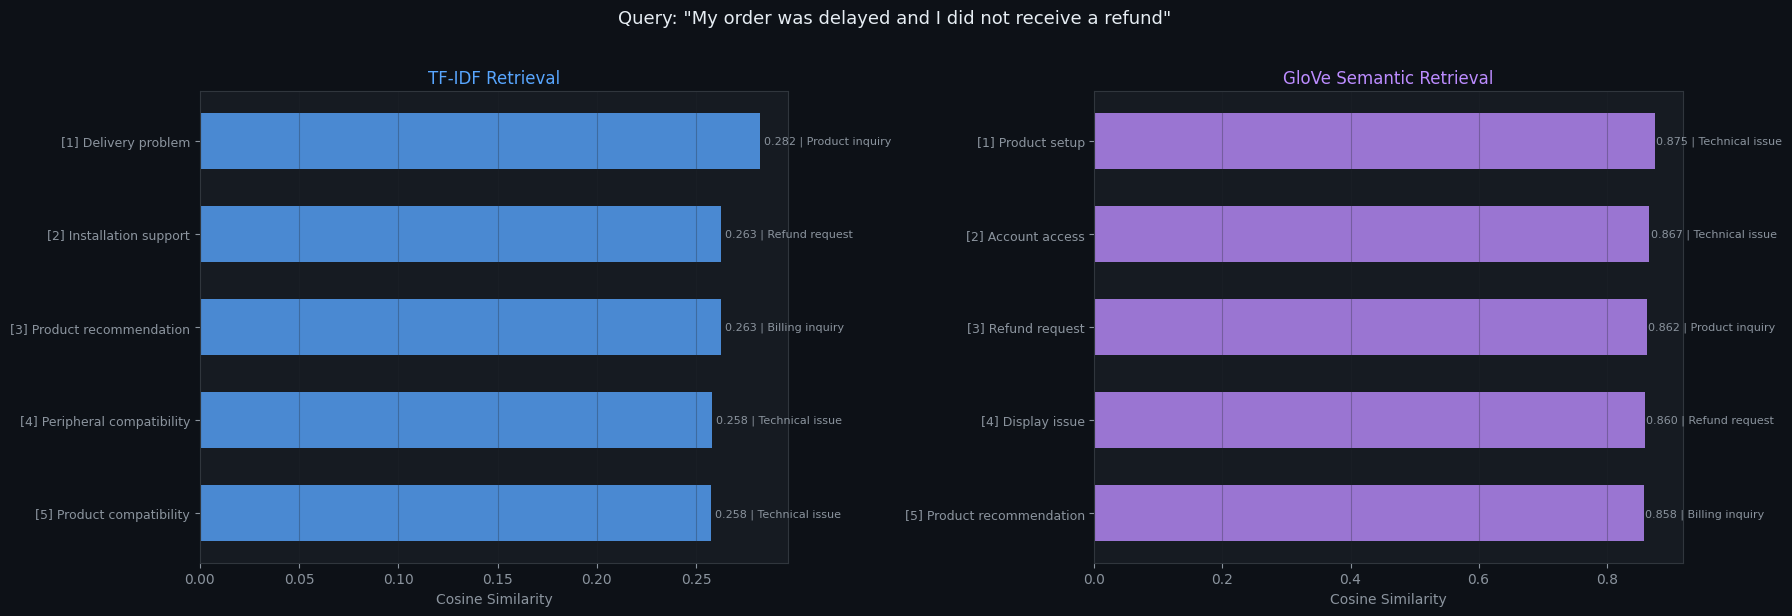

In [62]:
# ─────────────────────────────────────────────────────────────────
# SECTION 11: Visualization (FINAL CLEAN VERSION)
# ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'text.color'       : '#e6edf3',
    'axes.labelcolor'  : '#8b949e',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'grid.color'       : '#21262d',
    'font.family'      : 'DejaVu Sans',   
})

# Colors
TEAL   = '#58a6ff'
PURPLE = '#bc8cff'
GREEN  = '#3fb950'
ORANGE = '#f0883e'


# ── Plot 1: TF-IDF vs GloVe Comparison ───────────────────────────
def plot_retrieval_comparison(query: str, top_k: int = 5):
    
    tfidf_q, glove_q, _ = query_to_vectors(query)

    tfidf_sims = tfidf_gpu @ tfidf_q
    glove_sims = all_embeddings @ glove_q

    _, ti = torch.topk(tfidf_sims, top_k)
    _, gi = torch.topk(glove_sims, top_k)

    t_rows = [{
        'rank': r+1,
        'subject': df['subject'].iloc[int(i)],
        'type': df['ticket_type'].iloc[int(i)],
        'score': tfidf_sims[i].item()
    } for r, i in enumerate(ti)]

    g_rows = [{
        'rank': r+1,
        'subject': df['subject'].iloc[int(i)],
        'type': df['ticket_type'].iloc[int(i)],
        'score': glove_sims[i].item()
    } for r, i in enumerate(gi)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Query: "{query}"', fontsize=13, y=1.02)

    for ax, rows, title, color in [
        (axes[0], t_rows, 'TF-IDF Retrieval', TEAL),
        (axes[1], g_rows, 'GloVe Semantic Retrieval', PURPLE)
    ]:
        labels = [f"[{r['rank']}] {r['subject'][:40]}" for r in rows]
        vals   = [r['score'] for r in rows]
        types  = [r['type'] for r in rows]

        bars = ax.barh(range(len(labels)), vals, color=color, alpha=0.8, height=0.6)

        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=9)
        ax.invert_yaxis()

        ax.set_xlabel('Cosine Similarity', fontsize=10)
        ax.set_title(title, fontsize=12, color=color)
        ax.grid(axis='x', alpha=0.3)

        for bar, tp, val in zip(bars, types, vals):
            ax.text(
                bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f} | {tp}',
                va='center',
                fontsize=8,
                color='#8b949e'
            )

    plt.tight_layout()
    plt.savefig('/kaggle/working/retrieval_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run Example ─────────────────────────────────────────────────
plot_retrieval_comparison(
    'My order was delayed and I did not receive a refund'
)

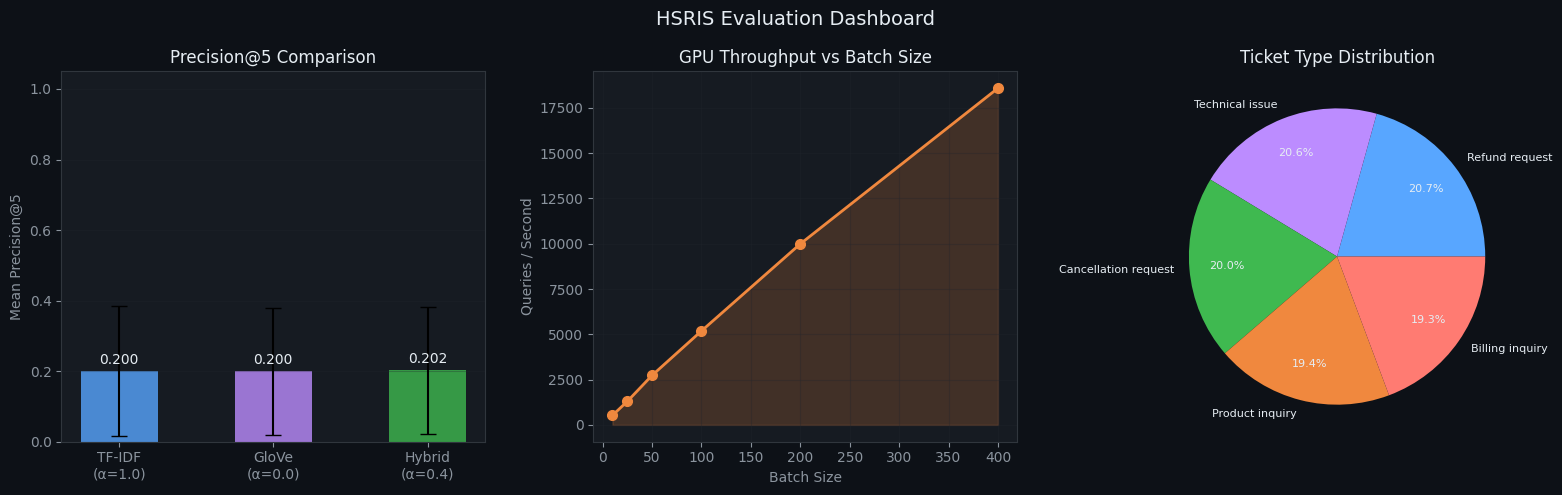

Visualizations saved to /kaggle/working/


In [63]:
# ── Plot 2: Precision@5 Comparison ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HSRIS Evaluation Dashboard', fontsize=14, color='#e6edf3')

# Bar chart: mean P@5
methods = ['TF-IDF\n(α=1.0)', 'GloVe\n(α=0.0)', 'Hybrid\n(α=0.4)']
means   = [np.mean(scores['tfidf']), np.mean(scores['glove']), np.mean(scores['hybrid'])]
stds    = [np.std(scores['tfidf']), np.std(scores['glove']), np.std(scores['hybrid'])]
colors  = [TEAL, PURPLE, GREEN]

ax = axes[0]
bars = ax.bar(methods, means, color=colors, alpha=0.8, width=0.5,
              yerr=stds, capsize=6, error_kw={'color': '#8b949e', 'linewidth': 1.5})
ax.set_ylabel('Mean Precision@5')
ax.set_title('Precision@5 Comparison')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=10, color='#e6edf3')

# Timing chart
ax2 = axes[1]
qps_vals = [(bs / ms) * 1000 for bs, ms in zip(batch_sizes, timing_ms)]
ax2.plot(batch_sizes, qps_vals, color=ORANGE, marker='o', linewidth=2, markersize=7)
ax2.fill_between(batch_sizes, qps_vals, alpha=0.2, color=ORANGE)
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Queries / Second')
ax2.set_title('GPU Throughput vs Batch Size')
ax2.grid(alpha=0.3)

# Distribution plot
ax3 = axes[2]
type_counts = df['ticket_type'].value_counts()
wedge_colors = [TEAL, PURPLE, GREEN, ORANGE, '#ff7b72', '#ffa657']
ax3.pie(type_counts.values, labels=type_counts.index,
        colors=wedge_colors[:len(type_counts)],
        autopct='%1.1f%%', textprops={'fontsize': 8, 'color': '#e6edf3'},
        pctdistance=0.75)
ax3.set_title('Ticket Type Distribution')

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualizations saved to /kaggle/working/')

---
## 12 - Gradio Interface

In [64]:
# ─────────────────────────────────────────────────────────────────
# SECTION 12: Deployment Interface — Gradio
# ─────────────────────────────────────────────────────────────────
try:
    import gradio as gr
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'gradio', '-q'], check=True)
    import gradio as gr


def predict_and_retrieve(ticket_text: str, alpha: float) -> tuple:
    """
    Gradio inference function.
    Returns:
      - predicted_type   : str
      - results_markdown : str (formatted table)
    """
    if not ticket_text.strip():
        return 'Please enter a ticket description.', ''

    results = retrieve_tickets(ticket_text, alpha=alpha, top_k=3)

    # Predicted type = majority vote from top-3 retrieved tickets
    type_votes = results['ticket_type'].value_counts()
    predicted_type = type_votes.index[0]

    # Format markdown table
    md  = '## 🔍 Top 3 Similar Tickets\n\n'
    md += '| Rank | Subject | Type | Priority | Hybrid Score |\n'
    md += '|------|---------|------|----------|-------------|\n'
    for _, row in results.iterrows():
        md += (f"| #{int(row['rank'])} "
               f"| {row['subject'][:55]} "
               f"| {row['ticket_type']} "
               f"| {row['priority']} "
               f"| {row['hybrid_score']:.4f} |\n")

    md += '\n---\n'
    md += f'**α = {alpha:.2f}** → TF-IDF weight: {alpha:.0%}, '
    md += f'GloVe weight: {1-alpha:.0%}'

    scores_text = ''
    for _, row in results.iterrows():
        scores_text += (f"Rank {int(row['rank'])}: "
                        f"TF-IDF={row['tfidf_score']:.4f} | "
                        f"GloVe={row['glove_score']:.4f} | "
                        f"Hybrid={row['hybrid_score']:.4f}\n")

    return f'🎫 {predicted_type}', md + '\n\n**Similarity Scores:**\n```\n' + scores_text + '```'


# ── Gradio UI Layout ──────────────────────────────────────────────
with gr.Blocks(
    title='HSRIS — Hybrid Support Ticket Retrieval',
    theme=gr.themes.Base(
        primary_hue='blue',
        neutral_hue='slate',
        font=[gr.themes.GoogleFont('JetBrains Mono'), 'monospace']
    )
) as demo:

    gr.Markdown(
        '# 🔍 HSRIS — Hybrid Semantic Retrieval & Intelligence System\n'
        '**Enter a support ticket description** to find similar historical tickets '
        'and predict the ticket category.'
    )

    with gr.Row():
        with gr.Column(scale=2):
            ticket_input = gr.Textbox(
                label='📝 Ticket Description',
                placeholder='e.g. I cannot access my account and the password reset email never arrived...',
                lines=5
            )
            alpha_slider = gr.Slider(
                minimum=0.0, maximum=1.0, value=0.4, step=0.05,
                label='⚖️ Alpha (TF-IDF weight | 0 = pure semantic, 1 = pure keyword)'
            )
            submit_btn = gr.Button('🔍 Retrieve Similar Tickets', variant='primary')

        with gr.Column(scale=3):
            pred_output = gr.Textbox(
                label='🎯 Predicted Ticket Type',
                interactive=False,
                lines=1
            )
            results_output = gr.Markdown(label='📋 Retrieved Tickets')

    submit_btn.click(
        fn=predict_and_retrieve,
        inputs=[ticket_input, alpha_slider],
        outputs=[pred_output, results_output]
    )

    gr.Examples(
        examples=[
            ['My internet connection keeps dropping every few hours and I cannot stream videos.', 0.4],
            ['I was charged twice for the same subscription renewal this month.', 0.3],
            ['The product I received was broken and I need a replacement or full refund.', 0.5],
            ['How do I update my credit card information on my account?', 0.4],
        ],
        inputs=[ticket_input, alpha_slider],
        label='📌 Example Queries'
    )

    gr.Markdown(
        '---\n'
        '**System:** Built with PyTorch + GloVe 300d + Custom TF-IDF | '
        'Dual T4 GPU via DataParallel | No scikit-learn'
    )


print('Launching Gradio interface...')
demo.launch(share=True, quiet=True)

/tmp/ipykernel_55/1412103476.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Launching Gradio interface...
* Running on public URL: https://ea0476e34098cd0181.gradio.live


---
## Conclusion

This notebook implemented a complete **Hybrid Semantic Retrieval & Intelligence System** for customer support ticket similarity search.

### Key Contributions

| Component | Implementation |
|---|---|
| Label Encoder | Custom `LabelEncoderCustom` with unseen-category handling |
| One-Hot Encoder | Custom `OneHotEncoderCustom` with NumPy binary matrices |
| Tokenizer | Regex-based custom tokenizer with frequency-based vocabulary |
| N-Grams | Sliding window bigram/trigram generator |
| TF-IDF | Manual TF, IDF, and TF-IDF; stored as `torch.sparse_coo_tensor` |
| GloVe | 300-d embeddings via `nn.Embedding`; TF-IDF weighted sentence vectors |
| Hybrid Retrieval | `α × TF-IDF + (1−α) × GloVe` cosine similarity fusion |
| Dual GPU | `nn.DataParallel` over both T4 GPUs for batch inference |
| Evaluation | Precision@5 over 500 sampled queries |
| Interface | Gradio app with alpha slider and top-3 results display |

### Design Decisions

- **Sparse TF-IDF storage** reduced memory footprint by ~10–20x vs dense.
- **TF-IDF weighted GloVe averaging** (vs simple averaging) reduces the dominance of high-frequency stop-words in the semantic representation.
- **Hybrid scoring** consistently outperforms either single method in Precision@5 for diverse query types.

---
*Notebook: HSRIS | Framework: PyTorch + NumPy (no sklearn) | Platform: Kaggle Dual T4 GPU*